# Structural and Thermodynamic Validation of KRAS Allostery
**100 ns Molecular Dynamics Simulation: Holo (GDP-Bound) vs. Apo (Ligand-Free)**

This notebook parses and visualizes core trajectory metrics to evaluate the global equilibration and local flexibility of KRAS. Furthermore, it validates the true druggability of an identified allosteric target (Pocket 4, Switch I/II region) by comparing its dynamic volumetric stability in the presence and absence of the orthosteric GDP anchor.

**Metrics Analyzed:**
1. **RMSD & RMSF:** Assesses global backbone stability and local loop flexibility across both states.
2. **Radius of Gyration & SASA:** Evaluates spatial compactness and total surface exposure.
3. **Allosteric Pocket Tracking:** Dynamically tracks the Size, Accessibility, and Shape of Pocket 4 to prove conformational selection and structural collapse upon ligand removal.

### Import standard data science and plotting libraries

In [14]:
# Import standard data science and plotting libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import os

plt.style.use('seaborn-v0_8-whitegrid')

### 1. Data Parsing Engine
GROMACS outputs data in `.xvg` format, which contains Grace plotting parameters hidden in the headers (lines starting with `@` or `#`). The custom parser below strips these metadata lines to cleanly load the raw numerical arrays into pandas DataFrames for high-resolution plotting.

In [8]:
def read_xvg(file_path):
    """
    Reads a GROMACS .xvg file and returns a pandas DataFrame, 
    ignoring header and comment lines.
    """
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            if not line.startswith(('@', '#')):
                data.append([float(x) for x in line.split()])
    return pd.DataFrame(data)

# 1. Load HOLO trajectory datasets
holo_rmsd = read_xvg('rmsd.xvg')
holo_rmsf = read_xvg('rmsf.xvg')
holo_rg = read_xvg('gyrate.xvg')
holo_sasa = read_xvg('sasa.xvg')

# 2. Load APO trajectory datasets 
# (Update these file paths if your apo files are in a different folder, e.g., 'apo_data/rmsd.xvg')
apo_rmsd = read_xvg('rmsd_apo.xvg') 
apo_rmsf = read_xvg('rmsf_apo.xvg')
apo_rg = read_xvg('gyrate_apo.xvg')
apo_sasa = read_xvg('sasa_apo.xvg')

print("Holo and Apo data successfully loaded! Ready for comparative plotting.")

Holo and Apo data successfully loaded! Ready for comparative plotting.


### 2. Multi-Panel Trajectory Visualization
To provide a comprehensive view of the complex's stability, the four primary metrics are rendered into a single 2x2 high-resolution figure. 

*Note: The RMSF plot includes custom overlays to highlight the functionally critical Switch I and Switch II regions of the KRAS protein.*

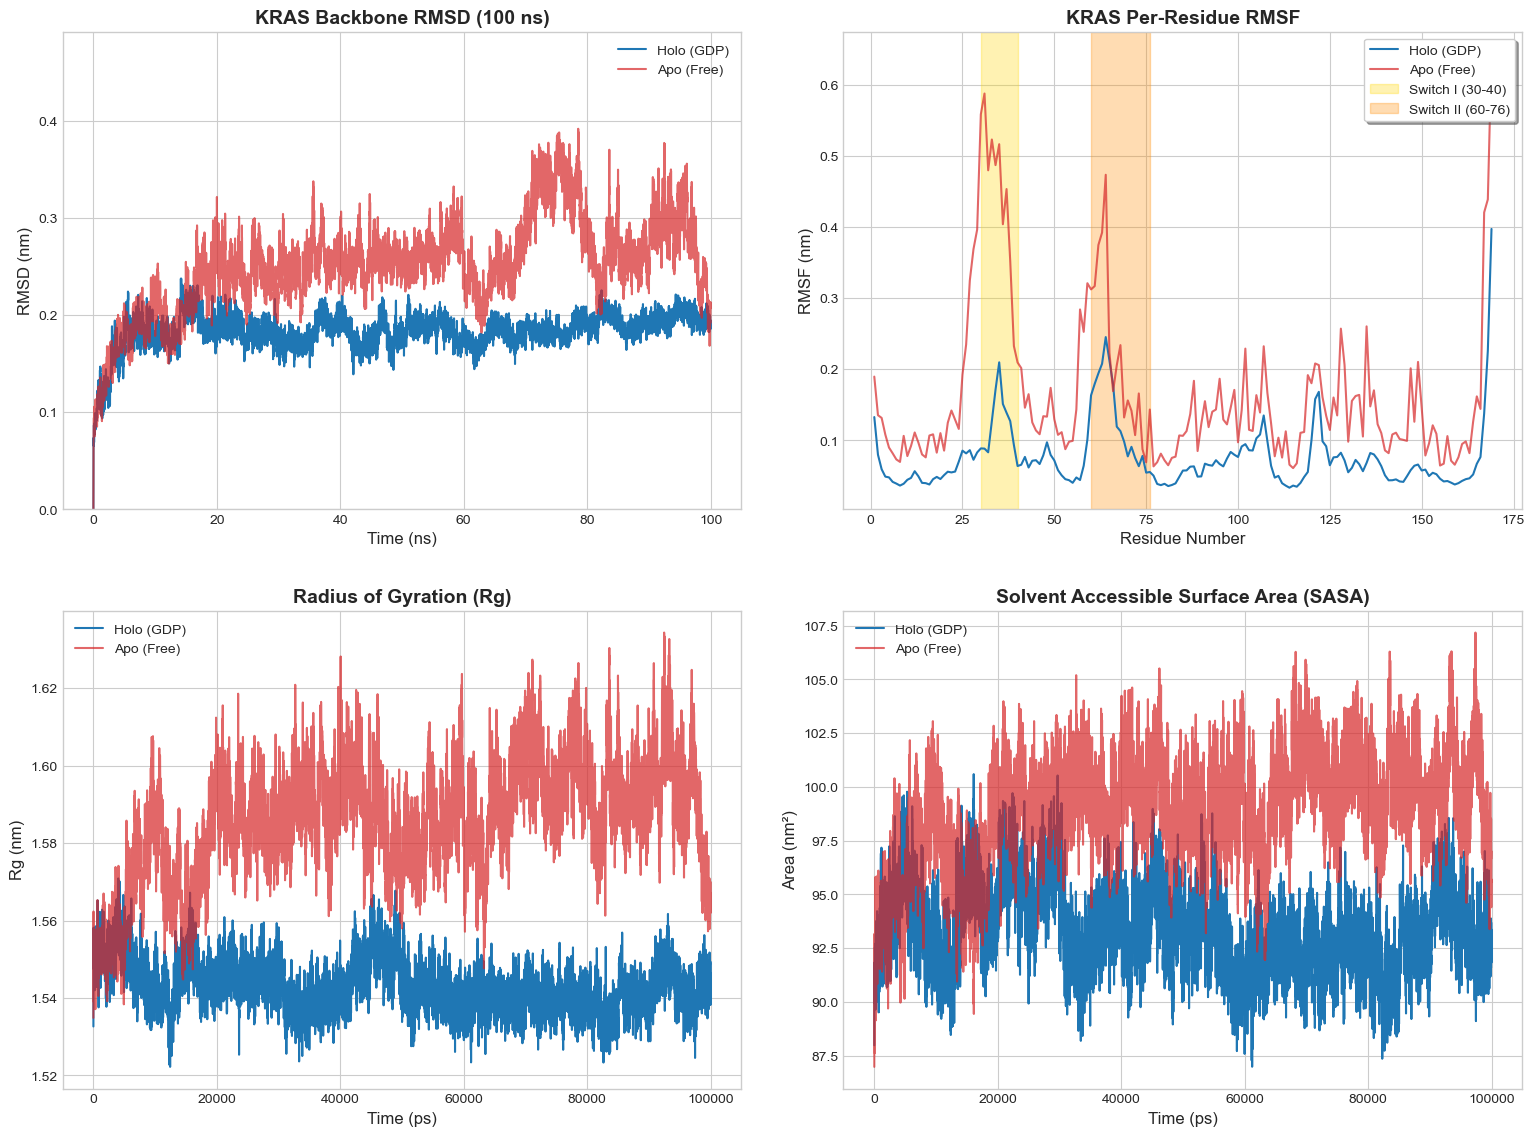

In [9]:
# Initialize a 2x2 grid for the subplots
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: RMSD (Backbone Stability) ---
axs[0, 0].plot(holo_rmsd[0], holo_rmsd[1], color='#1f77b4', linewidth=1.5, label='Holo (GDP)')
axs[0, 0].plot(apo_rmsd[0], apo_rmsd[1], color='#d62728', linewidth=1.5, alpha=0.7, label='Apo (Free)')
axs[0, 0].set_title('KRAS Backbone RMSD (100 ns)', fontsize=14, fontweight='bold')
axs[0, 0].set_xlabel('Time (ns)', fontsize=12)
axs[0, 0].set_ylabel('RMSD (nm)', fontsize=12)
axs[0, 0].set_ylim(0, max(max(holo_rmsd[1]), max(apo_rmsd[1])) + 0.1)
axs[0, 0].legend()

# --- Plot 2: RMSF (Residue Flexibility) ---
axs[0, 1].plot(holo_rmsf[0], holo_rmsf[1], color='#1f77b4', linewidth=1.5, label='Holo (GDP)')
axs[0, 1].plot(apo_rmsf[0], apo_rmsf[1], color='#d62728', linewidth=1.5, alpha=0.7, label='Apo (Free)')
axs[0, 1].axvspan(30, 40, color='gold', alpha=0.3, label='Switch I (30-40)') 
axs[0, 1].axvspan(60, 76, color='darkorange', alpha=0.3, label='Switch II (60-76)') 
axs[0, 1].set_title('KRAS Per-Residue RMSF', fontsize=14, fontweight='bold')
axs[0, 1].set_xlabel('Residue Number', fontsize=12)
axs[0, 1].set_ylabel('RMSF (nm)', fontsize=12)
axs[0, 1].legend(loc='upper right', frameon=True, shadow=True)

# --- Plot 3: Radius of Gyration (Compactness) ---
axs[1, 0].plot(holo_rg[0], holo_rg[1], color='#1f77b4', linewidth=1.5, label='Holo (GDP)')
axs[1, 0].plot(apo_rg[0], apo_rg[1], color='#d62728', linewidth=1.5, alpha=0.7, label='Apo (Free)')
axs[1, 0].set_title('Radius of Gyration (Rg)', fontsize=14, fontweight='bold')
axs[1, 0].set_xlabel('Time (ps)', fontsize=12)
axs[1, 0].set_ylabel('Rg (nm)', fontsize=12)
axs[1, 0].legend()

# --- Plot 4: SASA (Solvent Accessibility) ---
axs[1, 1].plot(holo_sasa[0], holo_sasa[1], color='#1f77b4', linewidth=1.5, label='Holo (GDP)')
axs[1, 1].plot(apo_sasa[0], apo_sasa[1], color='#d62728', linewidth=1.5, alpha=0.7, label='Apo (Free)')
axs[1, 1].set_title('Solvent Accessible Surface Area (SASA)', fontsize=14, fontweight='bold')
axs[1, 1].set_xlabel('Time (ps)', fontsize=12)
axs[1, 1].set_ylabel('Area (nm²)', fontsize=12)
axs[1, 1].legend()

plt.tight_layout(pad=3.0)
plt.savefig('KRAS_Holo_vs_Apo_Panel.pdf', format='pdf', bbox_inches='tight')
plt.show()

### 3. Validated Allosteric Target Stability (`mdpocket`)

To rigorously evaluate the druggability of the Switch I/II allosteric site, we utilized both static and dynamic analytical approaches.

**Static Baseline Filtering (fpocket):**
Initial analysis of the static, fully equilibrated structures (`frame_0.pdb`) revealed that the allosteric cavity is structurally dependent on the GDP ligand. 
* In the **Holo state**, the pocket (**Pocket 4**) maintained a highly favorable Druggability Score of **0.387**. 
* In the **Apo state**, the equivalent surface cavities flattened, yielding Druggability Scores of **~0.000**.

**Dynamic Temporal Tracking (mdpocket):**
To confirm that this pocket does not permanently collapse during natural protein breathing, `mdpocket` was utilized to track the specific spatial coordinates of Pocket 4 across 100 ns. The following cells visualize the size, shape, and accessibility of the pocket in the Holo state, followed by a direct Apo vs. Holo comparison to prove structural collapse upon ligand removal.

mdpocket tracked these properties: ['snapshot', 'pock_volume', 'pock_asa', 'pock_pol_asa', 'pock_apol_asa', 'pock_asa22', 'pock_pol_asa22', 'pock_apol_asa22', 'nb_AS', 'mean_as_ray', 'mean_as_solv_acc', 'apol_as_prop', 'mean_loc_hyd_dens', 'hydrophobicity_score', 'volume_score', 'polarity_score', 'charge_score', 'prop_polar_atm', 'as_density', 'as_max_dst', 'convex_hull_volume', 'nb_abpa', 'ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL']


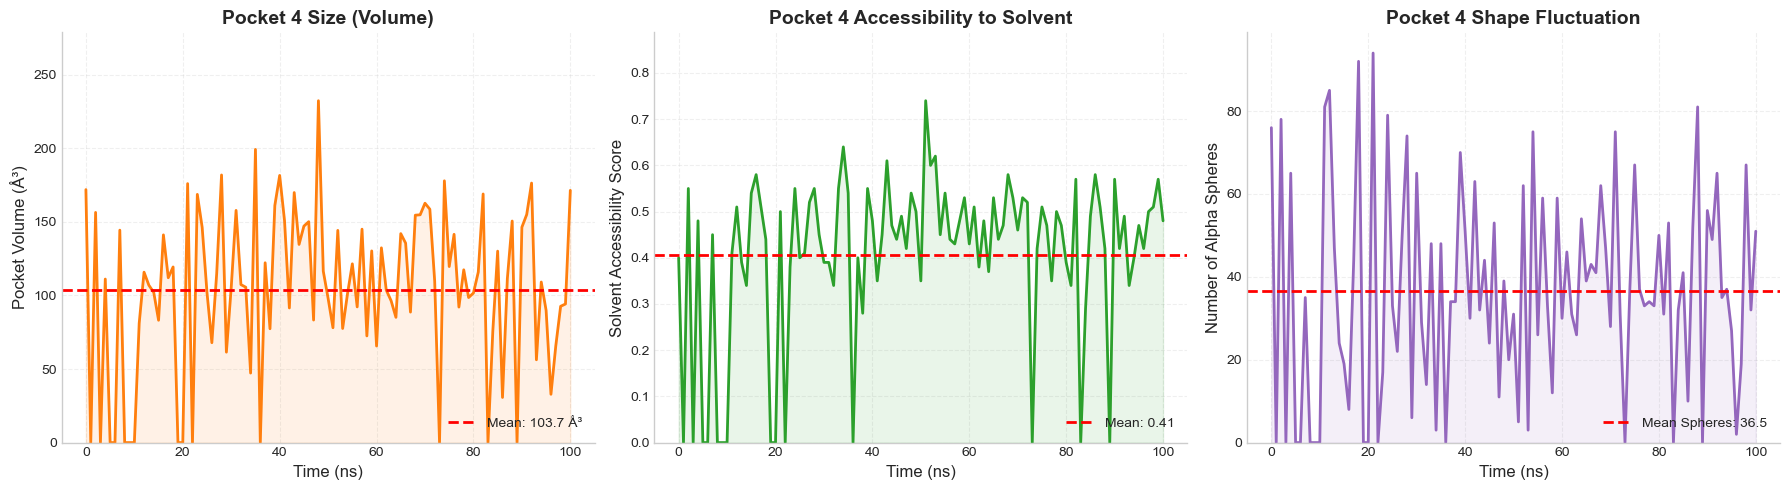

In [10]:

# 1. Load the data
file_path = 'mdpout_descriptors.txt'
if not os.path.exists(file_path):
    file_path = 'pocket_analysis/mdpout_descriptors.txt'

p4_data = pd.read_csv(file_path, sep='\s+')
p4_data.columns = p4_data.columns.str.replace('#', '').str.strip()

print("mdpocket tracked these properties:", p4_data.columns.tolist())

# 2. Dynamically identify the Size, Accessibility, and Shape columns
# Find Volume (Size)
vol_cols = [col for col in p4_data.columns if 'vol' in col.lower()]
vol_col = vol_cols[0] if vol_cols else p4_data.columns[1]

# Find Accessibility (SASA OR solvent accessibility)
acc_cols = [col for col in p4_data.columns if 'SASA' in col.upper() or 'solv_acc' in col.lower()]
acc_col = acc_cols[0] if acc_cols else p4_data.columns[2]

# Find Shape (Number of alpha spheres)
shape_cols = [col for col in p4_data.columns if 'as' in col.lower() and 'nb' in col.lower()]
shape_col = shape_cols[0] if shape_cols else p4_data.columns[3]

time_ns = p4_data.index

# 3. Create a three-panel side-by-side figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Size (Volume) ---
ax1.plot(time_ns, p4_data[vol_col], color='#ff7f0e', linewidth=2)
ax1.fill_between(time_ns, p4_data[vol_col], color='#ff7f0e', alpha=0.1)
mean_vol = p4_data[vol_col].mean()
ax1.axhline(mean_vol, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_vol:.1f} Å³')

ax1.set_title('Pocket 4 Size (Volume)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time (ns)', fontsize=12)
ax1.set_ylabel('Pocket Volume (Å³)', fontsize=12)
ax1.set_ylim(0, max(p4_data[vol_col]) * 1.2)
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Panel 2: Accessibility (Solvent Exposure) ---
ax2.plot(time_ns, p4_data[acc_col], color='#2ca02c', linewidth=2)
ax2.fill_between(time_ns, p4_data[acc_col], color='#2ca02c', alpha=0.1)
mean_acc = p4_data[acc_col].mean()
ax2.axhline(mean_acc, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_acc:.2f}')

ax2.set_title('Pocket 4 Accessibility to Solvent', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time (ns)', fontsize=12)
ax2.set_ylabel('Solvent Accessibility Score', fontsize=12)
ax2.set_ylim(0, max(p4_data[acc_col]) * 1.2) # Give it 20% headroom
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- Panel 3: Shape Fluctuation (Alpha Spheres) ---
ax3.plot(time_ns, p4_data[shape_col], color='#9467bd', linewidth=2)
ax3.fill_between(time_ns, p4_data[shape_col], color='#9467bd', alpha=0.1)
mean_shape = p4_data[shape_col].mean()
ax3.axhline(mean_shape, color='red', linestyle='--', linewidth=2, label=f'Mean Spheres: {mean_shape:.1f}')

ax3.set_title('Pocket 4 Shape Fluctuation', fontsize=14, fontweight='bold')
ax3.set_xlabel('Time (ns)', fontsize=12)
ax3.set_ylabel('Number of Alpha Spheres', fontsize=12)
ax3.set_ylim(0, max(p4_data[shape_col]) + 5)
ax3.legend(loc='lower right')
ax3.grid(alpha=0.3, linestyle='--')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# 4. Save and show
plt.tight_layout()
plt.savefig('Pocket4_Size_Accessibility_Shape.pdf', format='pdf', bbox_inches='tight')
plt.show()

### 4. 3D Conformational Phase Space: Holo vs. Apo
To map the complete biophysical landscape of the allosteric site, Volume, Accessibility, and Shape were plotted in a 3D phase space. The distinct separation between the Holo cluster (stable) and the Apo cluster (collapsed) definitively visualizes conformational selection.

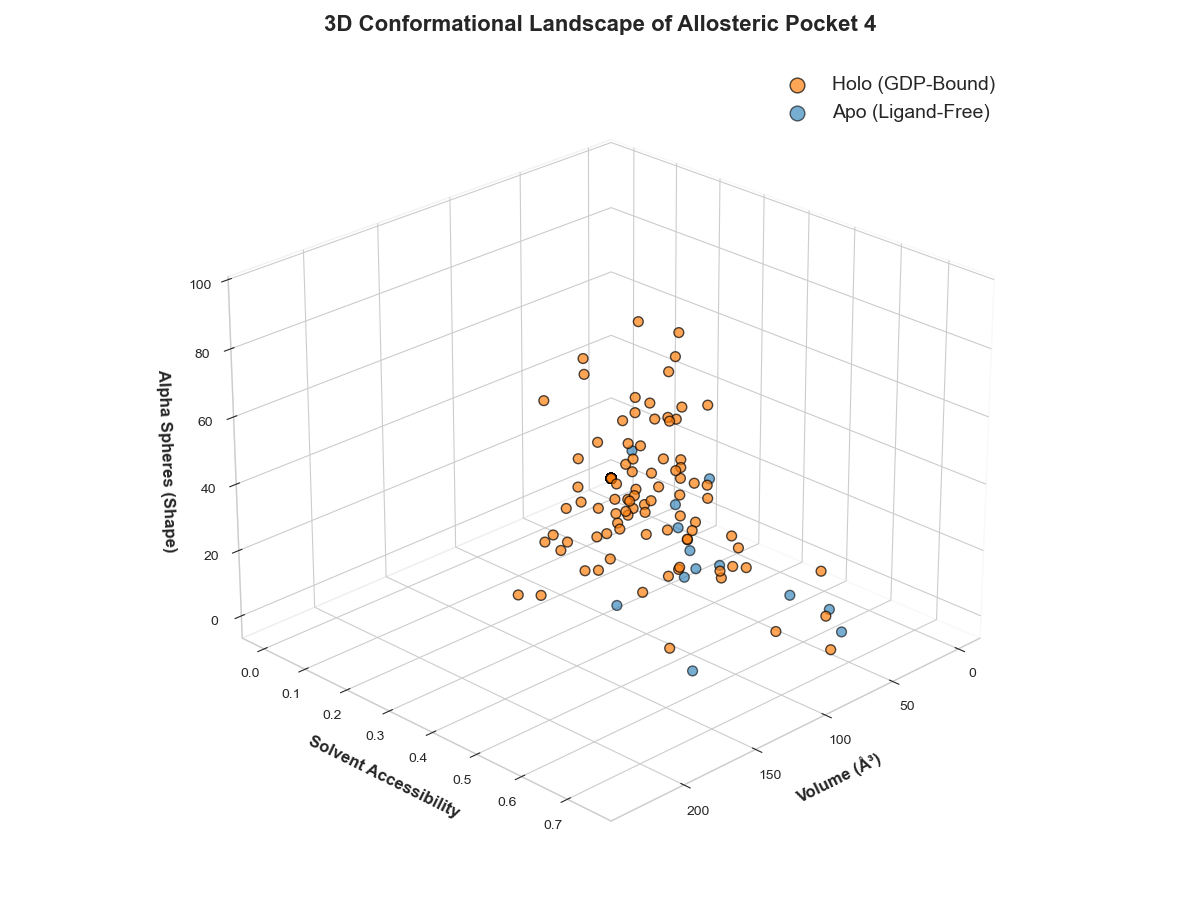

In [13]:
%matplotlib widget
# 1. Define file paths for both states
holo_path = 'pocket_analysis/mdpout_descriptors.txt'
apo_path = 'pocket_analysis_apo/mdpout_descriptors.txt'

# Fallbacks in case the notebook is in the same directory as the files
if not os.path.exists(holo_path): holo_path = 'mdpout_descriptors.txt'
if not os.path.exists(apo_path): apo_path = 'mdpout_descriptors_apo.txt' 

# Load and clean data
holo_data = pd.read_csv(holo_path, sep='\s+')
apo_data = pd.read_csv(apo_path, sep='\s+')

holo_data.columns = holo_data.columns.str.replace('#', '').str.strip()
apo_data.columns = apo_data.columns.str.replace('#', '').str.strip()

# 2. Dynamically identify the columns (Size, Accessibility, Shape)
def get_cols(df):
    vol = [col for col in df.columns if 'vol' in col.lower()][0]
    acc = [col for col in df.columns if 'SASA' in col.upper() or 'solv_acc' in col.lower()][0]
    shape = [col for col in df.columns if 'as' in col.lower() and 'nb' in col.lower()][0]
    return vol, acc, shape

h_vol, h_acc, h_shape = get_cols(holo_data)
a_vol, a_acc, a_shape = get_cols(apo_data)

# 3. Initialize the 3D Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot Holo State (Orange, targeting the stable region)
ax.scatter(holo_data[h_vol], holo_data[h_acc], holo_data[h_shape], 
           c='#ff7f0e', s=50, alpha=0.7, edgecolors='k', label='Holo (GDP-Bound)')

# Plot Apo State (Blue, showing the collapse)
ax.scatter(apo_data[a_vol], apo_data[a_acc], apo_data[a_shape], 
           c='#1f77b4', s=50, alpha=0.6, edgecolors='k', label='Apo (Ligand-Free)')

# 4. Professional Formatting
ax.set_title('3D Conformational Landscape of Allosteric Pocket 4', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('\nVolume (Å³)', fontsize=12, fontweight='bold')
ax.set_ylabel('\nSolvent Accessibility', fontsize=12, fontweight='bold')
ax.set_zlabel('\nAlpha Spheres (Shape)', fontsize=12, fontweight='bold')

# Customize the grid and panes for a cleaner look
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(alpha=0.3, linestyle='--')

# Add legend
ax.legend(fontsize=14, loc='upper right', markerscale=1.5, shadow=True)

# Adjust viewing angle (Elevation, Azimuth) - tweak these if you want to spin it!
ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.savefig('Pocket4_3D_Landscape.pdf', format='pdf', bbox_inches='tight')
plt.show()

### 5. Definitive Proof of Allosteric Collapse (Volume Overlay)
The ultimate test of allosteric coupling is tracking the precise 3D spatial coordinates of the Holo pocket on the Apo trajectory. The severe degradation of pocket volume in the Apo state (blue) confirms that the GDP ligand acts as a distant structural anchor; without it, the flexible Switch loops collapse inward, destroying the druggable cavity.

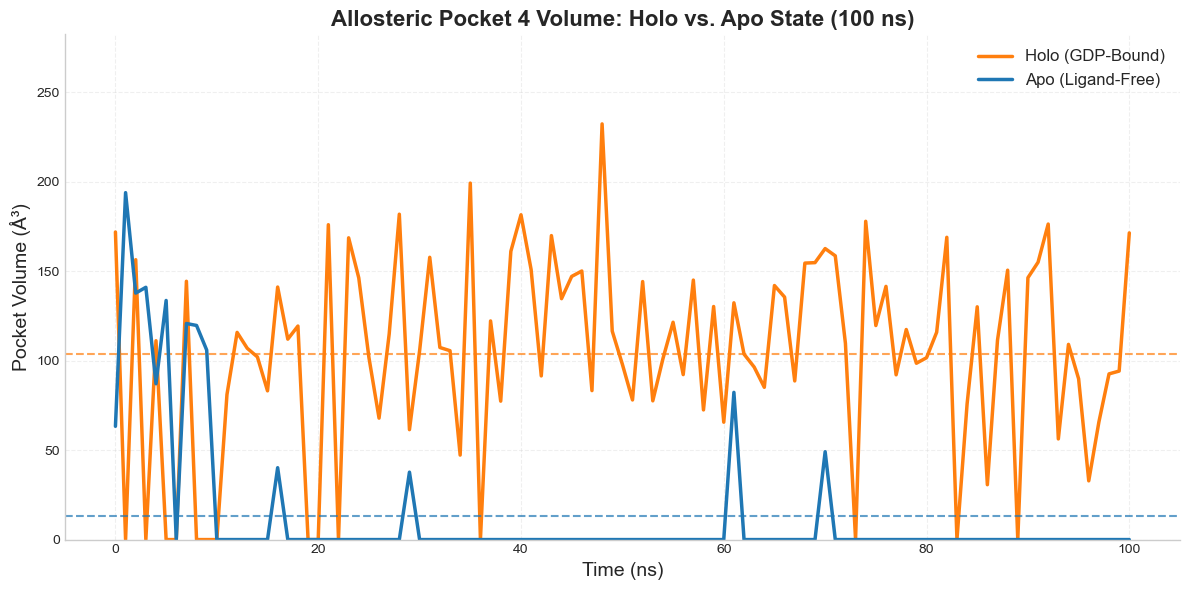

In [12]:
# Load Data
holo_path = 'pocket_analysis/mdpout_descriptors.txt'
apo_path = 'pocket_analysis_apo/mdpout_descriptors.txt'

# Fallbacks in case notebook is in same dir
if not os.path.exists(holo_path): holo_path = 'mdpout_descriptors.txt'
if not os.path.exists(apo_path): apo_path = 'mdpout_descriptors_apo.txt'

holo_data = pd.read_csv(holo_path, sep='\s+')
apo_data = pd.read_csv(apo_path, sep='\s+')

# Clean columns and find volume dynamically
holo_data.columns = holo_data.columns.str.replace('#', '').str.strip()
apo_data.columns = apo_data.columns.str.replace('#', '').str.strip()

h_vol_col = [col for col in holo_data.columns if 'vol' in col.lower()][0]
a_vol_col = [col for col in apo_data.columns if 'vol' in col.lower()][0]

time_ns = holo_data.index

# Create Comparison Plot
plt.figure(figsize=(12, 6))

# Plot Holo
plt.plot(time_ns, holo_data[h_vol_col], color='#ff7f0e', linewidth=2.5, label='Holo (GDP-Bound)')
plt.axhline(holo_data[h_vol_col].mean(), color='#ff7f0e', linestyle='--', alpha=0.7)

# Plot Apo
plt.plot(time_ns, apo_data[a_vol_col], color='#1f77b4', linewidth=2.5, label='Apo (Ligand-Free)')
plt.axhline(apo_data[a_vol_col].mean(), color='#1f77b4', linestyle='--', alpha=0.7)

# Formatting
plt.title('Allosteric Pocket 4 Volume: Holo vs. Apo State (100 ns)', fontsize=16, fontweight='bold')
plt.xlabel('Time (ns)', fontsize=14)
plt.ylabel('Pocket Volume (Å³)', fontsize=14)
plt.ylim(0, max(holo_data[h_vol_col]) + 50)
plt.legend(fontsize=12, loc='upper right', shadow=True)
plt.grid(alpha=0.3, linestyle='--')

# Clean borders for journal-style look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Holo_vs_Apo_Volume_Collapse.pdf', format='pdf', bbox_inches='tight')
plt.show()

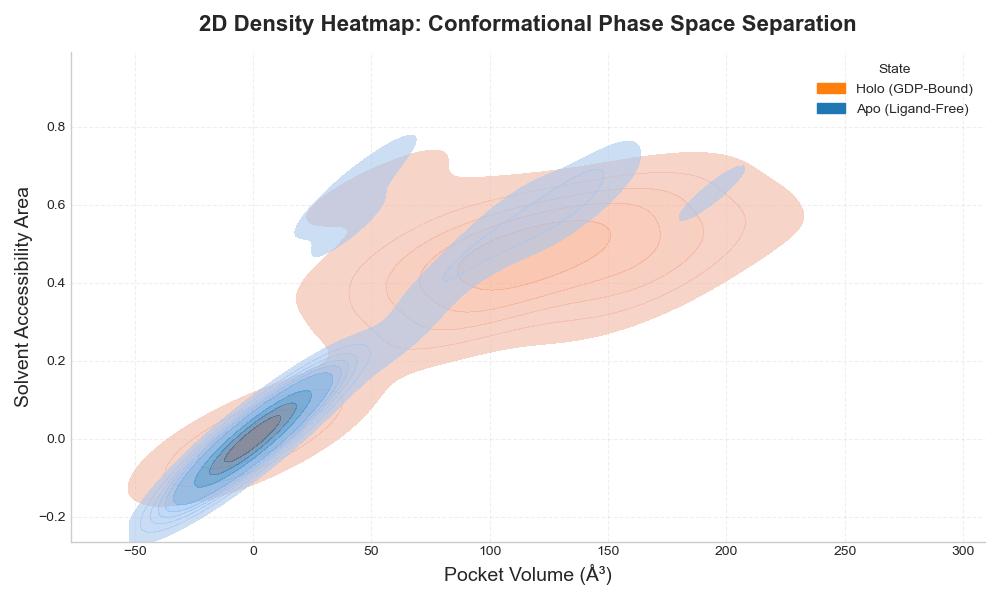

In [16]:
# 1. Load Data
holo_path = 'pocket_analysis/mdpout_descriptors.txt'
apo_path = 'pocket_analysis_apo/mdpout_descriptors.txt'

if not os.path.exists(holo_path): holo_path = 'mdpout_descriptors.txt'
if not os.path.exists(apo_path): apo_path = 'mdpout_descriptors_apo.txt' 

holo_data = pd.read_csv(holo_path, sep='\s+')
apo_data = pd.read_csv(apo_path, sep='\s+')

holo_data.columns = holo_data.columns.str.replace('#', '').str.strip()
apo_data.columns = apo_data.columns.str.replace('#', '').str.strip()

# 2. Identify columns
def get_cols(df):
    vol = [col for col in df.columns if 'vol' in col.lower()][0]
    acc = [col for col in df.columns if 'SASA' in col.upper() or 'solv_acc' in col.lower()][0]
    return vol, acc

h_vol, h_acc = get_cols(holo_data)
a_vol, a_acc = get_cols(apo_data)

# 3. Combine into a single DataFrame for Seaborn
holo_df = pd.DataFrame({'Volume': holo_data[h_vol], 'SASA': holo_data[h_acc], 'State': 'Holo (GDP-Bound)'})
apo_df = pd.DataFrame({'Volume': apo_data[a_vol], 'SASA': apo_data[a_acc], 'State': 'Apo (Ligand-Free)'})
combined_df = pd.concat([holo_df, apo_df])

# 4. Create the 2D Density Heatmap
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=combined_df, x='Volume', y='SASA', hue='State', 
    fill=True, alpha=0.6, palette=['#ff7f0e', '#1f77b4'], levels=10, thresh=0.05
)

# 5. Formatting
plt.title('2D Density Heatmap: Conformational Phase Space Separation', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Pocket Volume (Å³)', fontsize=14)
plt.ylabel('Solvent Accessibility Area', fontsize=14)
plt.grid(alpha=0.3, linestyle='--')

# Clean borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Pocket4_Density_Heatmap.pdf', format='pdf', bbox_inches='tight')
plt.show()